# `Project Assignment`

### Quantum Random Number Generator for Secure Keys

### Problem Statement:

Build a Quantum Random Number Generator (QRNG) using single-qubit measurements in 
superposition states. Using QRNG output to generate a sample cryptrographic key and 
compare it with classical pusedo-random key. Demonstrate how the quantum key offers
stranger randomness and better security.

### method to apply QRNG

The simplest form of a QRNG uses a single qubit and a basic quantum circuit made of two main steps:

* Step 1: Apply a Hadamard Gate
    A Hadamard Gate puts the qubit into a state where it has an equal chance of being measured as 0 and 1.
    This is called a superposition.

* Step 2: Measure the Qubit
    Once the qubit is measured, it randomly collapses to either 0 or 1. This result is
    unpredictable and cannot be influenced by any outside factor.

In [12]:
# import essintials 

from braket.circuits import Circuit
from braket.devices import LocalSimulator
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

### 1. Quantum Random Bit Generator

In [4]:
# Create simulator
device = LocalSimulator()

# Function to generate quantum random bits
def generate_qrng_bits(shots=1000):
    circuit = Circuit().h(0).measure(0)

    task = device.run(circuit, shots=shots)
    result = task.result()

    # Extract measurement
    measurements = result.measurements
    bits = [str(int(m[0])) for m in measurements]

    return ''.join(bits)

# Generate quantum random bits
quantum_bits = generate_qrng_bits(1000)

print("Quantum Bitstrings (first 100 bits: )")
print(quantum_bits[:100])

Quantum Bitstrings (first 100 bits: )
1101110100000010110001010011011001001101011000101010110100110110011111110110111111101001101001000000


### 2. Classical Psuedo-Random Generator

In [5]:
import random

def generate_classical_bit(n=1000, seed=42):
    random.seed(seed) # predictable!
    return ''.join(str(random.randint(0,1)) for _ in range(n))

classical_bits = generate_classical_bit(1000)
print("\nClassical Bitstring (first 100 bits): ")
print(classical_bits[:100])


Classical Bitstring (first 100 bits): 
0010000010000000101100111001001011101010110000100011110110100001110100011100101110100111100100000101


### 3. Statistical Test (0s vs 1s)


Quantum Randomness
0s: 492, 1s: 508


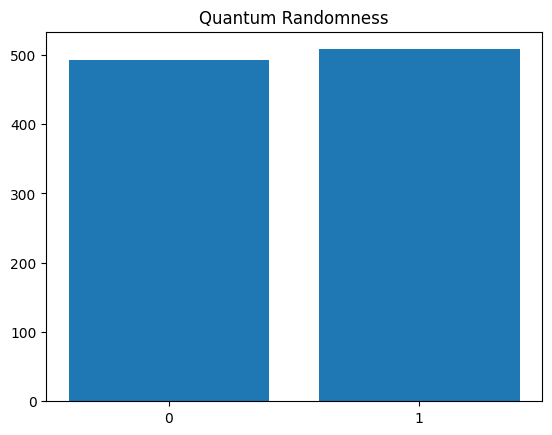


Classical Randomness
0s: 486, 1s: 514


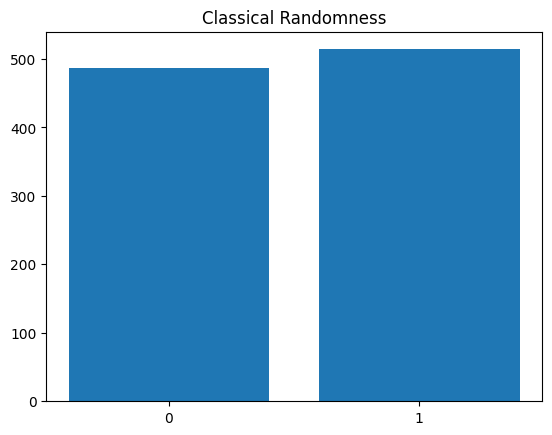

In [6]:
def analzye_bits(bitstring, title=""):
    count = Counter(bitstring)

    zeros = count['0']
    ones = count['1']

    print(f"\n{title}")
    print(f"0s: {zeros}, 1s: {ones}" )

    # Plot histogram
    plt.bar(['0', '1'], [zeros, ones])
    plt.title(title)    
    plt.show()

analzye_bits(quantum_bits, "Quantum Randomness")
analzye_bits(classical_bits, "Classical Randomness")




### 4. Shannon Entropy Calculation

In [7]:
import math

def shannon_entropy(bitstring):
    count = Counter(bitstring)
    total = len(bitstring)

    entropy = 0
    for bit in count:
        p = count[bit] / total
        entropy -= p * math.log2(p)

    return entropy

q_entropy = shannon_entropy(quantum_bits)
c_entropy = shannon_entropy(classical_bits)

print("\nEntropy Comparision")
print(f"Quantum Entropy: {q_entropy}")
print(f"Classical Entropy: {c_entropy}")


Entropy Comparision
Quantum Entropy: 0.9998153271549207
Classical Entropy: 0.9994343896240241


### 5. Generate Cryptrographic Key

In [8]:
# Convert bistring to hex key
def bits_to_hex(bitstring):
    return hex(int(bitstring, 2))

quantum_key = bits_to_hex(quantum_bits[:128])
classical_key = bits_to_hex(classical_bits[:128])

print("\nGenrated Keys: ")
print("Quantum Key: ", quantum_key)
print("Classical Key: ", classical_key)


Genrated Keys: 
Quantum Key:  0xdd02c5364d62ad367f6fe9a40a447950
Classical Key:  0x2080b392eac23da1d1cba7905e6d4933


### 6. Key Comparison (Important Insight)

In [9]:
# Show repeatability of classical key

classical_bits_repeat = generate_classical_bit(1000, seed=42)

print("\nClassical keys identical: ", 
      classical_bits == classical_bits_repeat)

# Quantum will NEVER match
quantum_bits_2 = generate_classical_bit(1000)

print("Quantum keys identical: ",
      quantum_bits == quantum_bits_2)


Classical keys identical:  True
Quantum keys identical:  False
